# Part 1 — Dataset, EDA, and Shared Preprocessing

**Owner: Phùng Bảo Khang**

This notebook presents the data foundation used by every model in the project: strict dataset validation, exploratory analysis, binary target encoding, the official stratified split, and leakage-safe one-hot preprocessing. It calls the shared modules under `src/`; it does not duplicate a second data pipeline.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').is_dir() and (candidate / 'data' / 'bank-full.csv').is_file():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the Lab 2 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / 'data' / 'bank-full.csv'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
pd.set_option('display.max_columns', 20)
display(Markdown(f'**Project root:** `{PROJECT_ROOT}`'))

**Project root:** `/home/pbkhang404/Documents/HCMUS/Y2/S3/ai/lab-2`

## 1. Load and validate the source dataset

`src.data.load_bank_data()` checks the exact 17-column schema, feature types and domains, semantic numerical bounds, missing values, duplicate rows, unique row indices, and the two target labels before any analysis runs.

In [2]:
from src.data import (
    CATEGORICAL_FEATURES,
    NUMERICAL_FEATURES,
    TARGET_MAPPING,
    load_bank_data,
    make_stratified_split,
    split_features_target,
)
from src.eda import build_eda_report, build_split_report
from src.experiment_contract import RANDOM_STATE, TEST_SIZE
from src.visualization import generate_eda_figures

frame = load_bank_data(DATA_PATH)
X, y = split_features_target(frame)
split = make_stratified_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
eda = build_eda_report(frame)
split_audit = build_split_report(split)
figure_paths = generate_eda_figures(frame, split, FIGURES_DIR)

dataset_summary = pd.DataFrame(
    {
        'Value': [
            eda['dataset']['rows'],
            eda['dataset']['columns_including_target'],
            eda['dataset']['input_features'],
            eda['dataset']['numerical_features'],
            eda['dataset']['categorical_features'],
            eda['dataset']['missing_values'],
            eda['dataset']['duplicate_rows'],
        ]
    },
    index=[
        'Rows', 'Columns including target', 'Input features',
        'Numerical features', 'Categorical features',
        'True missing values', 'Fully duplicated rows',
    ],
)
display(dataset_summary)
display(frame.head())

,Value
Rows,45211
Columns including target,17
Input features,16
Numerical features,7
Categorical features,9
True missing values,0
Fully duplicated rows,0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Target distribution and class imbalance

The target is mapped once as `no → 0` and `yes → 1`. Because `yes` is the minority class, later model comparisons must supplement Accuracy with positive-class Precision, Recall, F1, and ROC-AUC.

,Original label,Encoded label,Count,Percentage
0,no,0,39922,88.3015
1,yes,1,5289,11.6985


`no` is **7.55×** as frequent as `yes`.

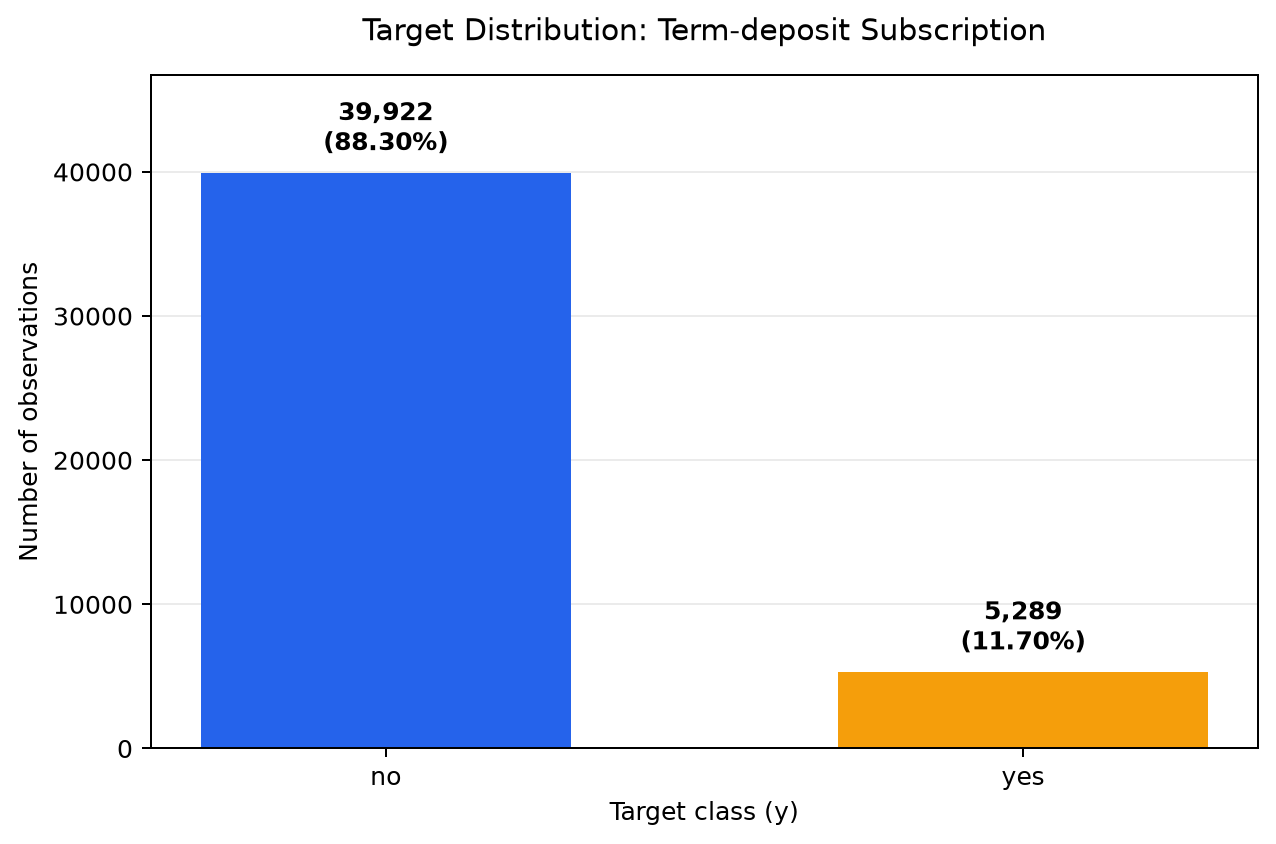

In [3]:
target_table = pd.DataFrame(
    [
        {
            'Original label': label,
            'Encoded label': TARGET_MAPPING[label],
            'Count': values['count'],
            'Percentage': values['percentage'],
        }
        for label, values in eda['target'].items()
    ]
)
imbalance_ratio = eda['target']['no']['count'] / eda['target']['yes']['count']
display(target_table)
display(Markdown(f'`no` is **{imbalance_ratio:.2f}×** as frequent as `yes`.'))
display(Image(filename=str(FIGURES_DIR / 'target-distribution.png'), width=760, alt='Bank Marketing target class distribution'))

## 3. Numerical and categorical EDA

Numerical predictors are not scaled because Decision Trees split on thresholds and do not depend on feature magnitude. The literal value `unknown` is retained as a documented category rather than converted to `NaN`. `pdays=-1` means the client was not previously contacted and is also retained.

### Numerical summary

,min,mean,median,max
Feature,,,,
age,18.0,40.936,39.0,95.0
balance,-8019.0,1362.272,448.0,102127.0
day,1.0,15.806,16.0,31.0
duration,0.0,258.163,180.0,4918.0
campaign,1.0,2.764,2.0,63.0
pdays,-1.0,40.198,-1.0,871.0
previous,0.0,0.580,0.0,275.0


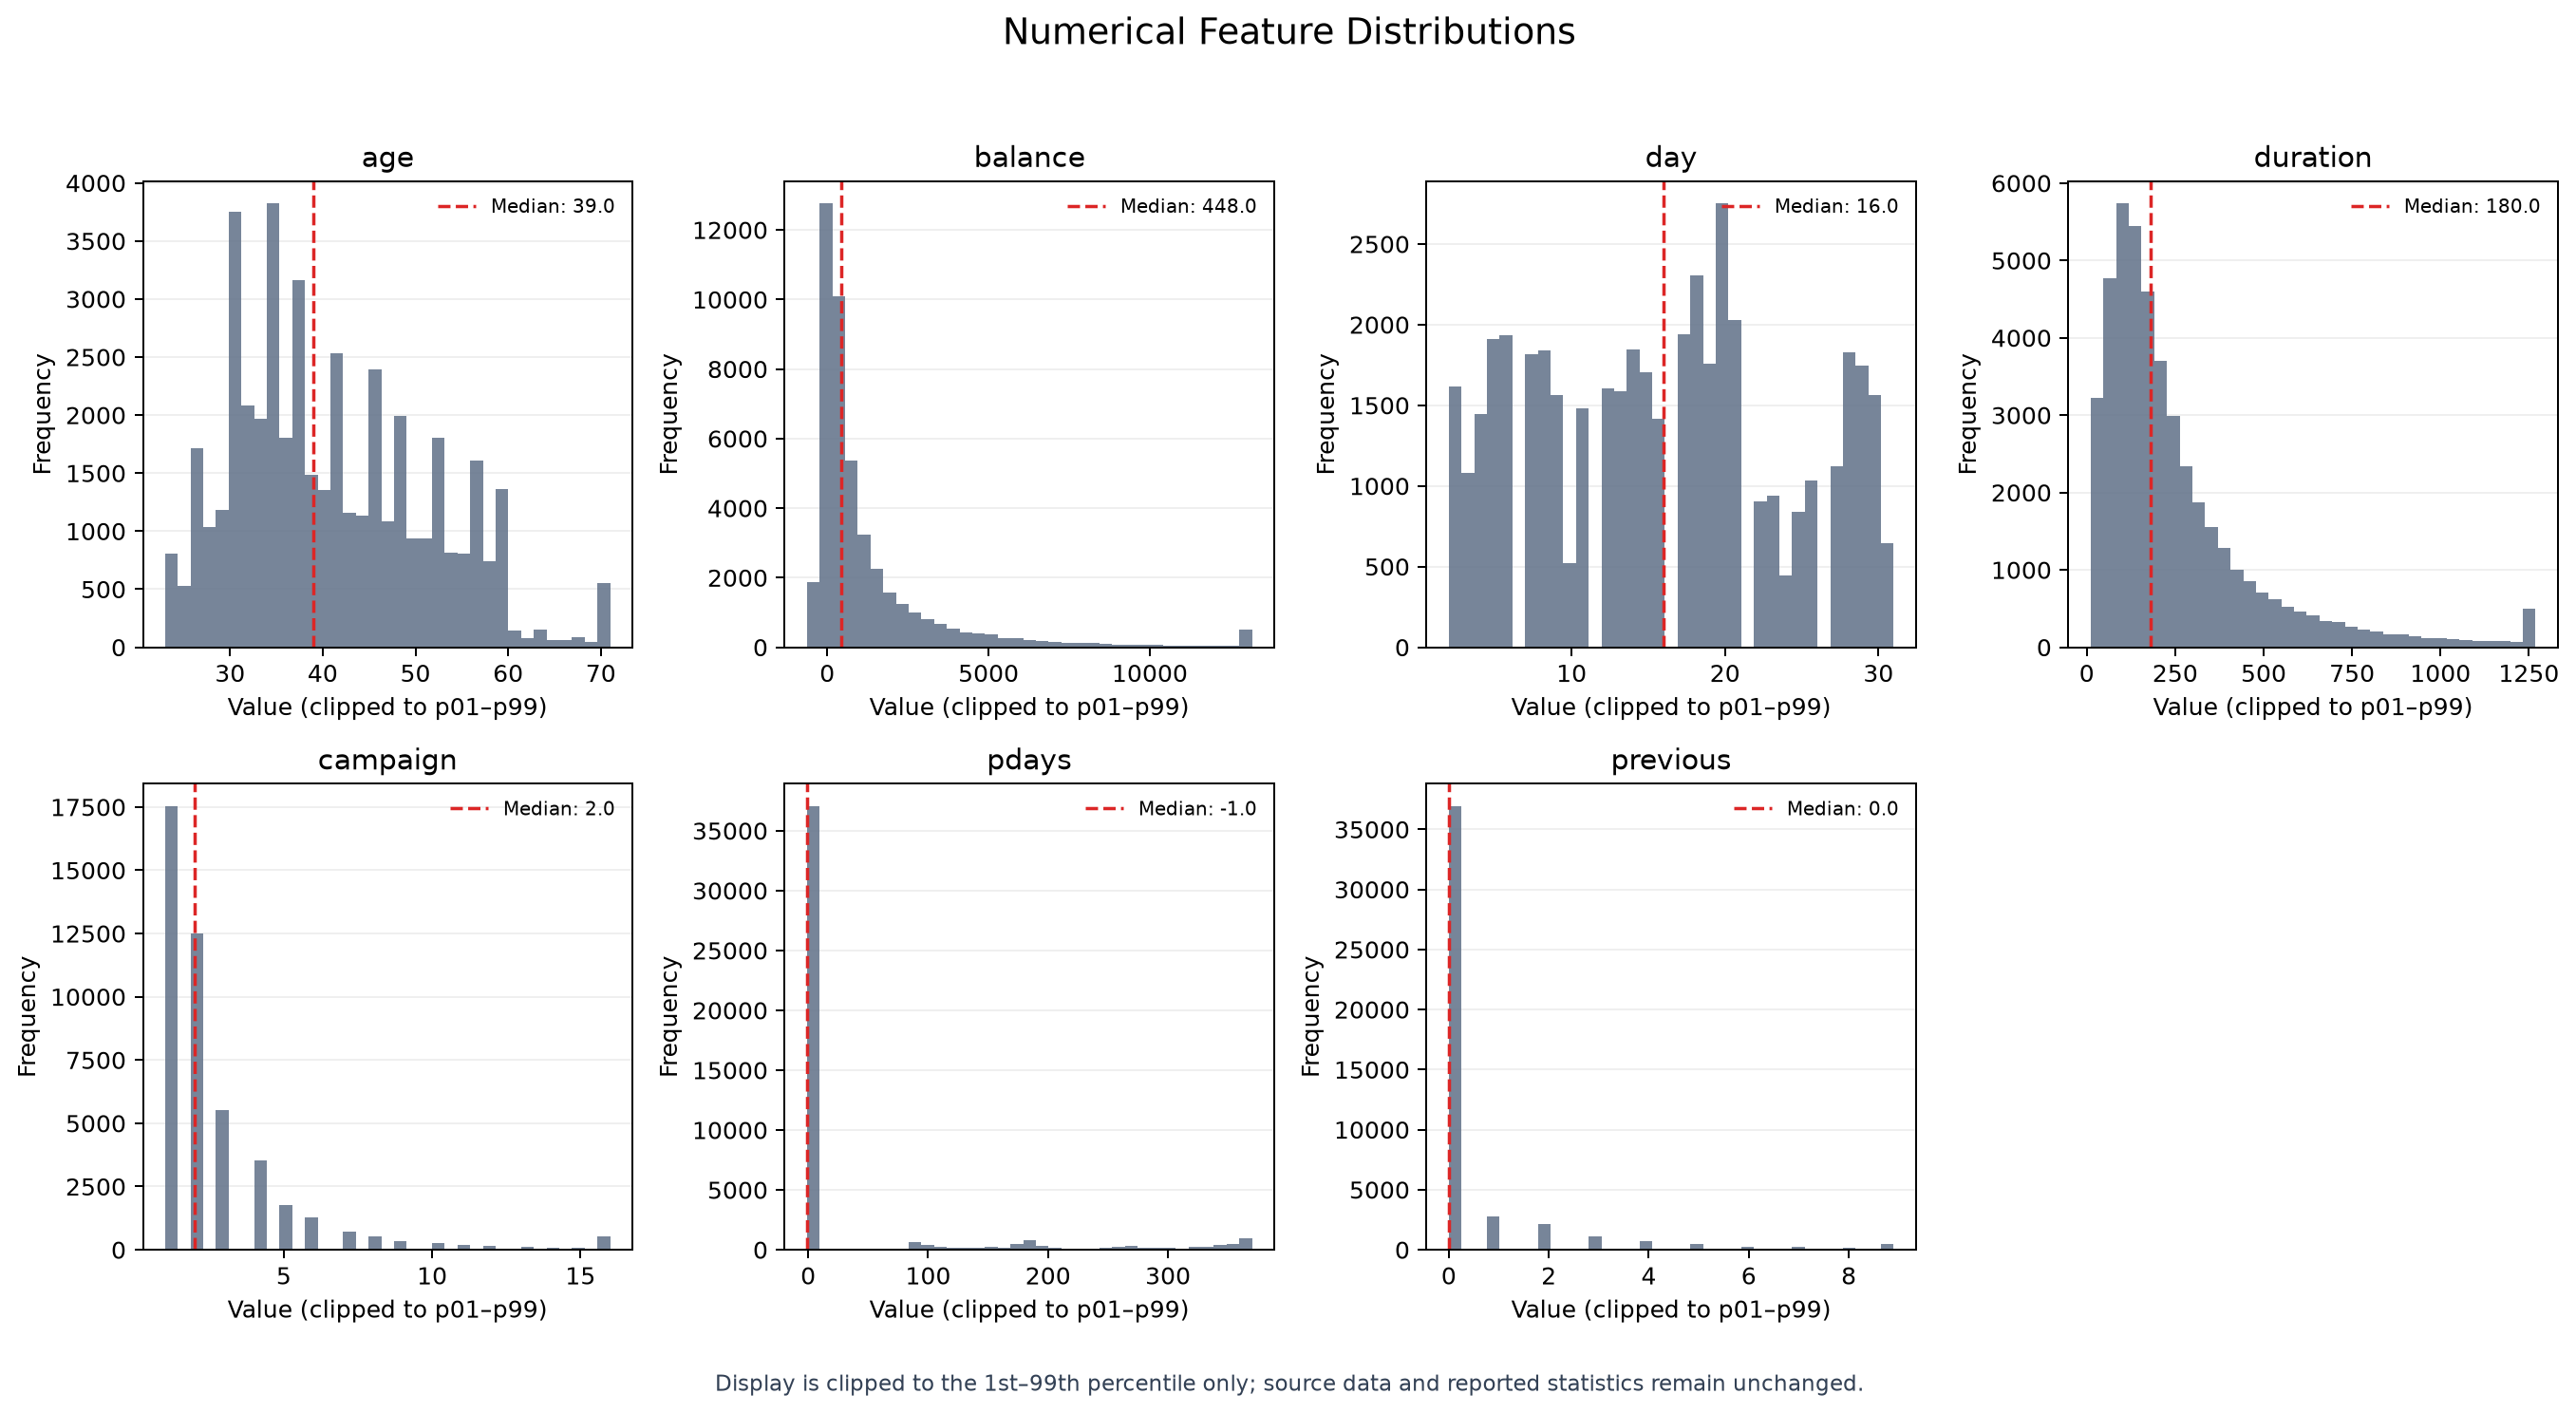

### Categorical summary

,Categories,Values equal to unknown
Feature,,
job,12,288
marital,3,0
education,4,1857
default,2,0
housing,2,0
loan,2,0
contact,3,13020
month,12,0
poutcome,4,36959


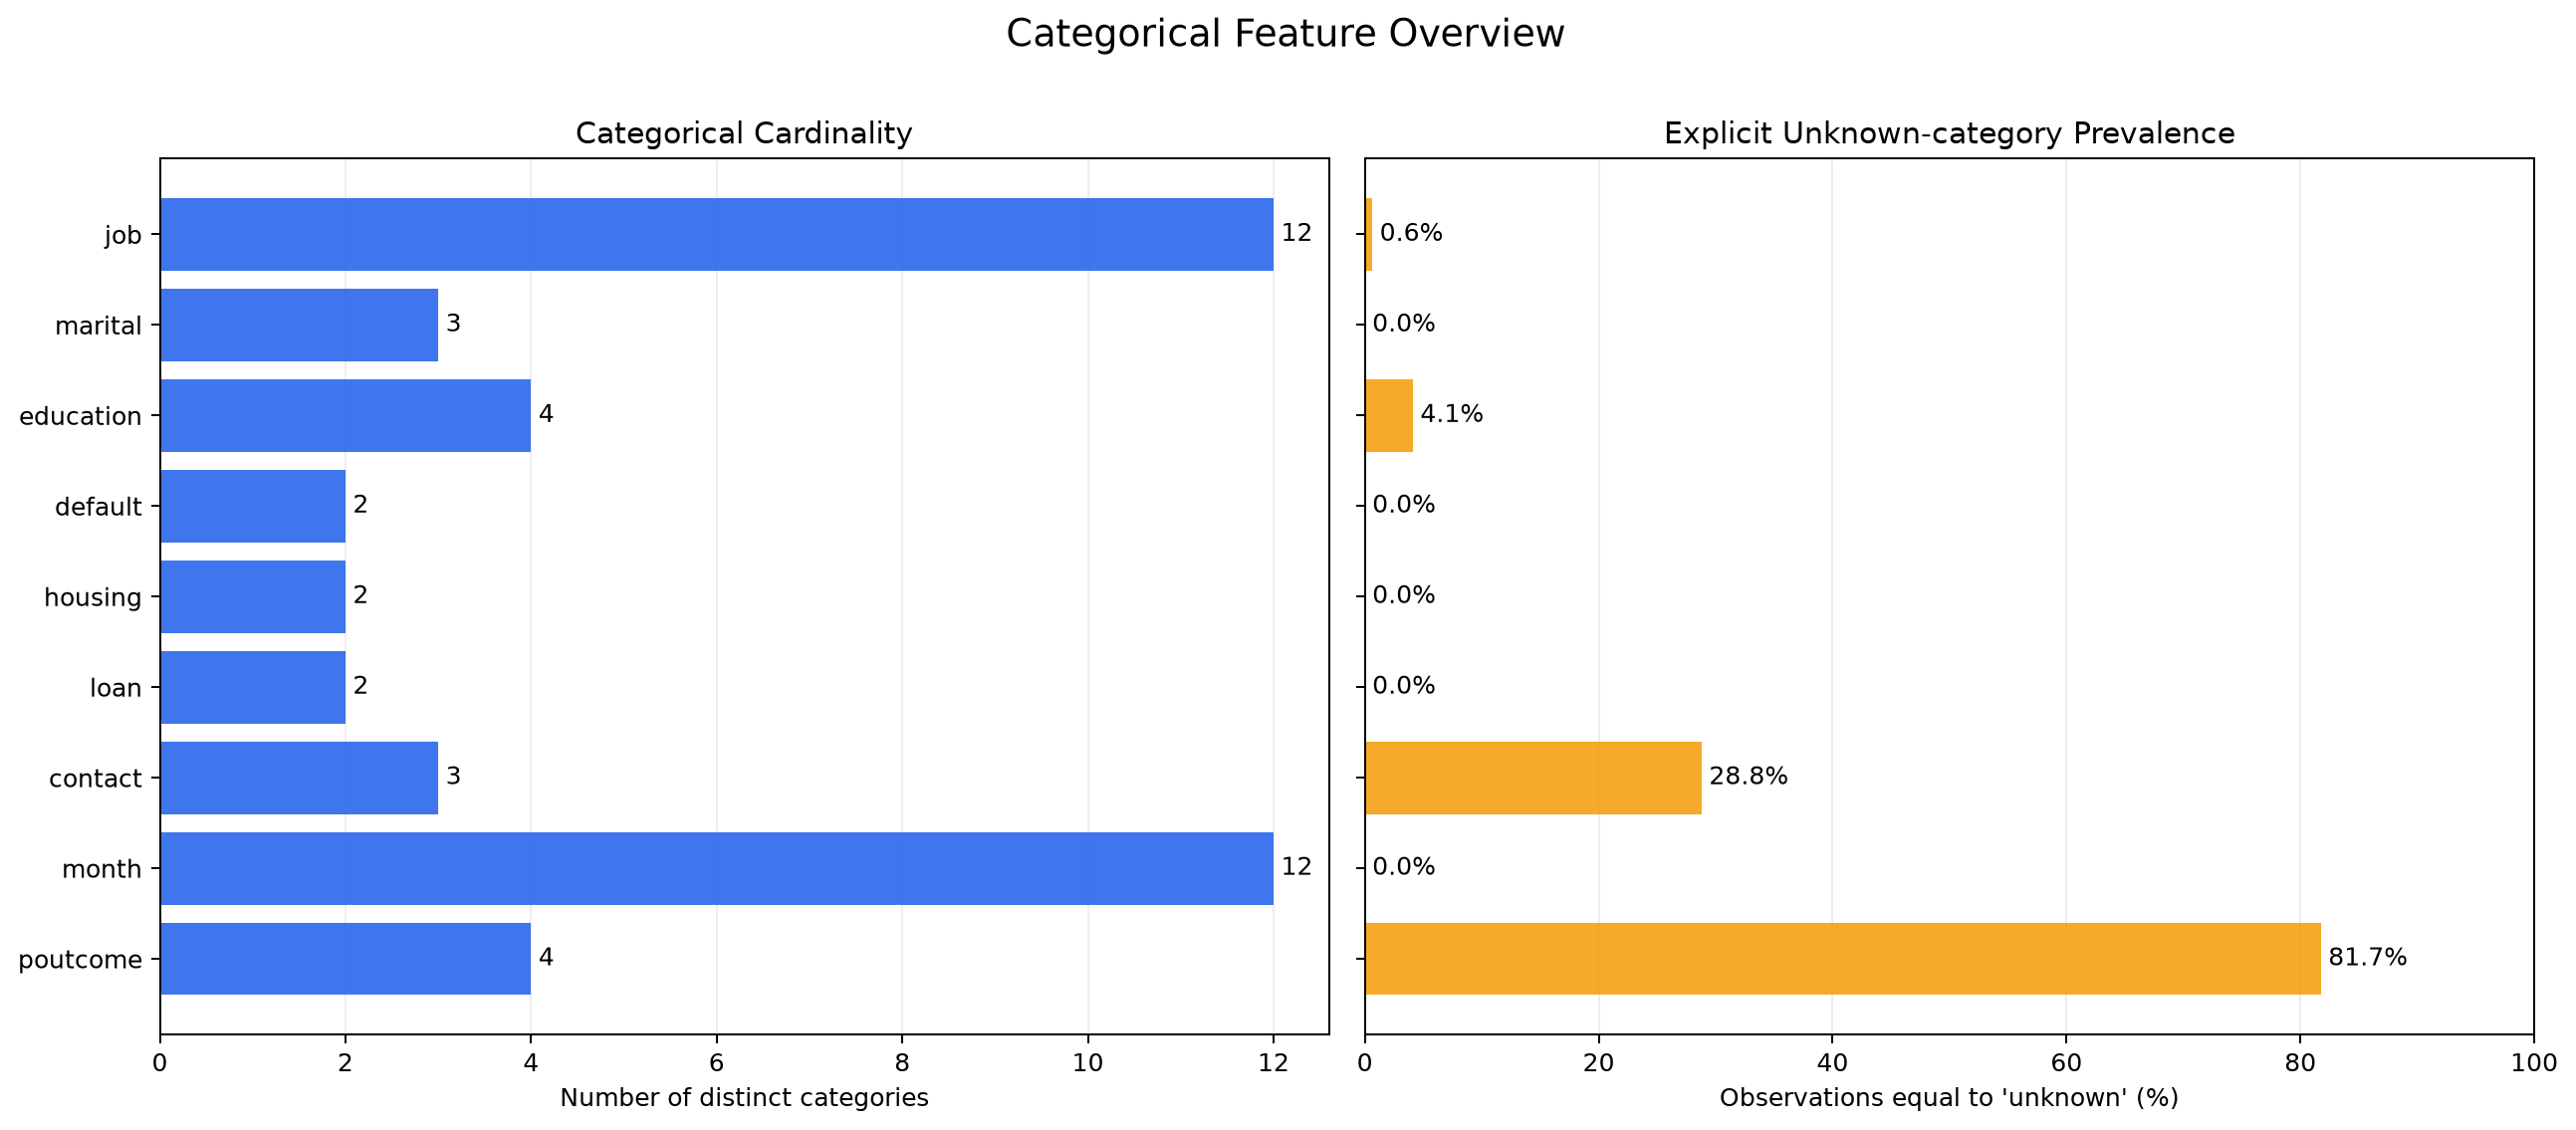

In [4]:
numeric_summary = pd.DataFrame(eda['numeric_summary']).T
numeric_summary.index.name = 'Feature'
categorical_summary = pd.DataFrame(
    {
        'Categories': eda['categorical_cardinality'],
        'Values equal to unknown': eda['explicit_unknown_counts'],
    }
)
categorical_summary.index.name = 'Feature'

display(Markdown('### Numerical summary'))
display(numeric_summary.round(3))
display(Image(filename=str(FIGURES_DIR / 'numeric-distributions.png'), width=980, alt='Distributions of the seven numerical predictors'))
display(Markdown('### Categorical summary'))
display(categorical_summary)
display(Image(filename=str(FIGURES_DIR / 'categorical-overview.png'), width=980, alt='Category counts for the nine categorical predictors'))

### Deployment caveat: `duration`

Call duration is only fully known after a marketing call ends. Keeping it is valid for the official post-call lab experiment, but it cannot be used by a system deciding whom to call in advance. The project therefore reports a separate pre-call sensitivity experiment without `duration`; this is a feature-availability limitation, not train/test leakage in this pipeline.

In [5]:
duration = frame['duration']
display(
    pd.DataFrame(
        {
            'Value': [duration.min(), duration.median(), duration.mean(), duration.max()]
        },
        index=['Minimum', 'Median', 'Mean', 'Maximum'],
    ).round(3)
)

,Value
Minimum,0.000
Median,180.000
Mean,258.163
Maximum,4918.000


## 4. Official stratified train/test split

The shared contract uses `test_size=0.20`, `random_state=42`, and `stratify=y`. Original row indices are preserved so disjointness and completeness can be audited.

,Partition,Rows,no / 0,no (%),yes / 1,yes (%)
0,Train,36168,31937,88.3018,4231,11.6982
1,Test,9043,7985,88.3003,1058,11.6997


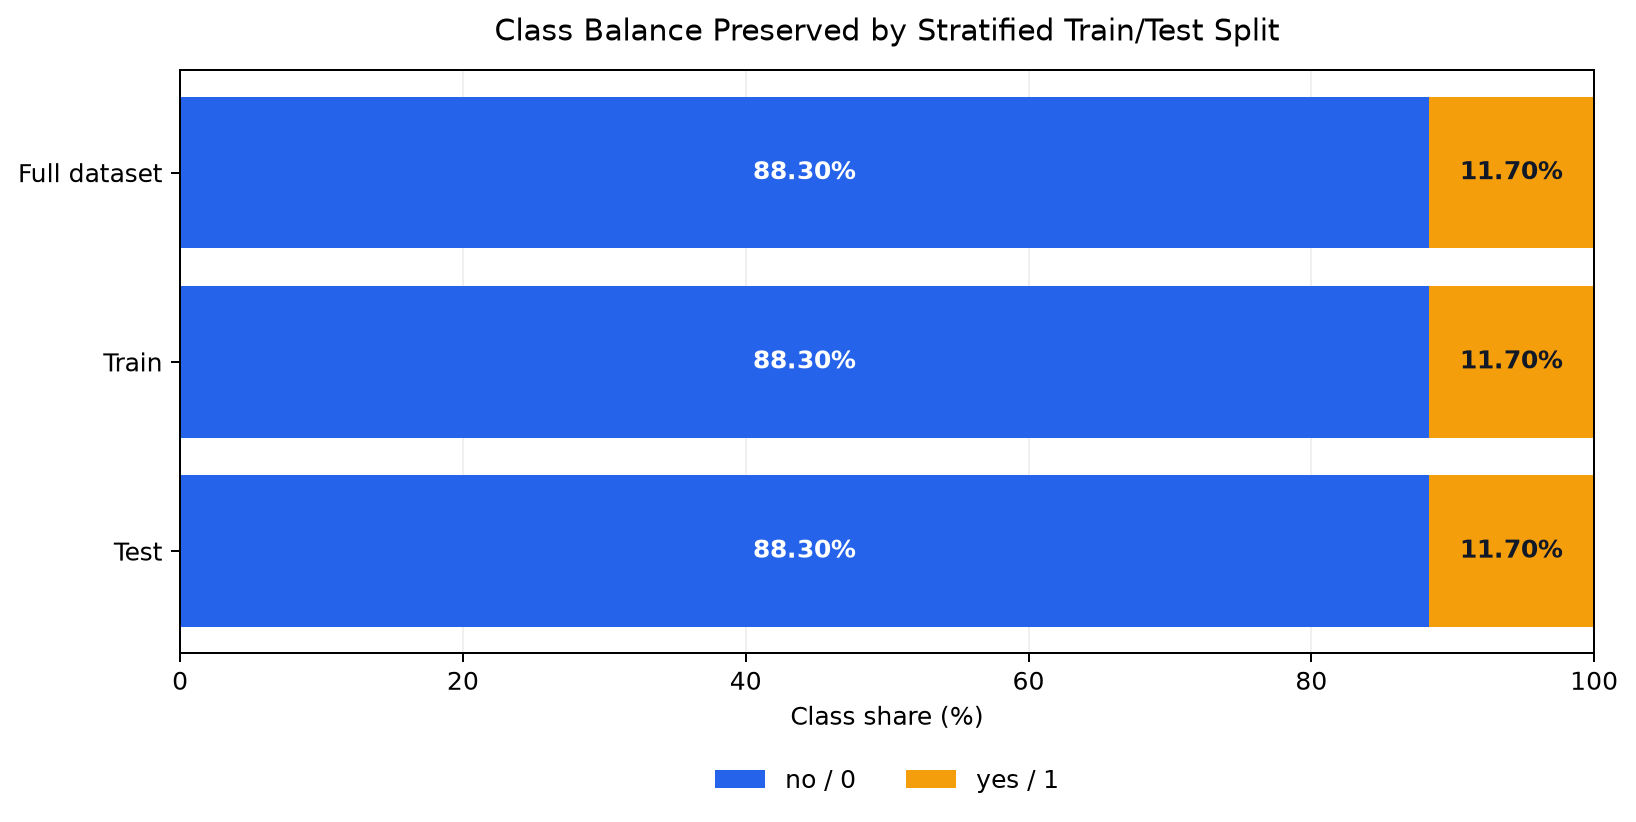

In [6]:
split_table = pd.DataFrame(
    [
        {
            'Partition': name.title(),
            'Rows': values['rows'],
            'no / 0': values['target']['0']['count'],
            'no (%)': values['target']['0']['percentage'],
            'yes / 1': values['target']['1']['count'],
            'yes (%)': values['target']['1']['percentage'],
        }
        for name, values in (
            ('train', split_audit['train']),
            ('test', split_audit['test']),
        )
    ]
)
display(split_table)
display(Image(filename=str(FIGURES_DIR / 'stratified-split-balance.png'), width=760, alt='Class balance in the full, training, and test partitions'))

## 5. Leakage-safe shared preprocessing

The `ColumnTransformer` one-hot encodes nine categorical features with `handle_unknown='ignore'` and passes seven numerical features through unchanged. It is fitted on `X_train` only; `X_test` is transform-only. For cross-validation, teammates use `build_model_pipeline(estimator)` so the encoder is refitted inside each training fold.

In [7]:
from src.preprocessing import (
    build_model_pipeline,
    build_preprocessing_pipeline,
    get_encoded_feature_names,
)

preprocessing = build_preprocessing_pipeline()
X_train_encoded = preprocessing.fit_transform(split.X_train)
X_test_encoded = preprocessing.transform(split.X_test)
feature_names = get_encoded_feature_names(preprocessing)

encoding_summary = pd.DataFrame(
    {
        'Raw shape': [split.X_train.shape, split.X_test.shape],
        'Encoded shape': [X_train_encoded.shape, X_test_encoded.shape],
    },
    index=['Train', 'Test'],
)
display(encoding_summary)
display(
    pd.DataFrame(
        {
            'Feature group': ['Categorical', 'Numerical', 'Encoded total'],
            'Count': [len(CATEGORICAL_FEATURES), len(NUMERICAL_FEATURES), len(feature_names)],
        }
    )
)
display(pd.DataFrame({'Encoded feature name': feature_names}).head(20))

,Raw shape,Encoded shape
Train,"(36168, 16)","(36168, 51)"
Test,"(9043, 16)","(9043, 51)"


,Feature group,Count
0,Categorical,9
1,Numerical,7
2,Encoded total,51


,Encoded feature name
0,job_admin.
1,job_blue-collar
2,job_entrepreneur
3,job_housemaid
4,job_management
5,job_retired
6,job_self-employed
7,job_services
8,job_student
9,job_technician


## 6. Leakage and handoff audit

These assertions make the notebook fail loudly if the shared contract changes or if the target reaches the feature matrices. An unseen future category is also transformed to demonstrate the inference-time policy.

In [8]:
unseen = split.X_test.iloc[:1].copy()
unseen.loc[:, 'job'] = 'future-unseen-category'
unseen_shape = preprocessing.transform(unseen).shape

audit = {
    'Train/test indices are disjoint': not bool(
        set(split.X_train.index) & set(split.X_test.index)
    ),
    'Split is exhaustive': len(split.X_train) + len(split.X_test) == len(frame),
    'Target excluded from raw predictors': 'y' not in split.X_train.columns,
    'Target excluded from encoded features': 'y' not in feature_names,
    'Train/test encoded columns align': X_train_encoded.shape[1] == X_test_encoded.shape[1],
    'Unseen category is accepted': unseen_shape == (1, len(feature_names)),
}
assert all(audit.values()), audit
display(pd.DataFrame({'Check': audit.keys(), 'Passed': audit.values()}))

,Check,Passed
0,Train/test indices are disjoint,True
1,Split is exhaustive,True
2,Target excluded from raw predictors,True
3,Target excluded from encoded features,True
4,Train/test encoded columns align,True
5,Unseen category is accepted,True


## 7. Shared pipeline handoff

Later experiments must call `load_and_split_data()` and `build_model_pipeline(estimator)` instead of creating a new split or encoder. This keeps every baseline, tuning, pruning, and class-weight result directly comparable.

In [9]:
from sklearn.tree import DecisionTreeClassifier

handoff_pipeline = build_model_pipeline(
    DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
)
display(handoff_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",1.0
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_na

## Conclusion

Khang's part establishes one validated dataset and one reproducible preprocessing contract for the whole team. The official split contains 36,168 training rows and 9,043 test rows; one-hot encoding produces 51 aligned features; preprocessing never fits on test data; and the class imbalance plus `duration` availability caveat are made explicit before modeling begins.